In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import json
import torch
import os
import copy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import multilabel_confusion_matrix, classification_report, roc_curve, auc, confusion_matrix, \
     RocCurveDisplay, precision_score, recall_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score
from tqdm import tqdm
from matplotlib.pyplot import figure


In [2]:
from matplotlib import rc, rcParams
rc('axes', linewidth=1)
rc('font', size=7)
plt.rcParams['font.family'] = 'Arial'

In [3]:
cog_labels = ['amy_label', 'tau_label']

In [5]:
df = pd.read_csv("./source_data/efig1.csv")

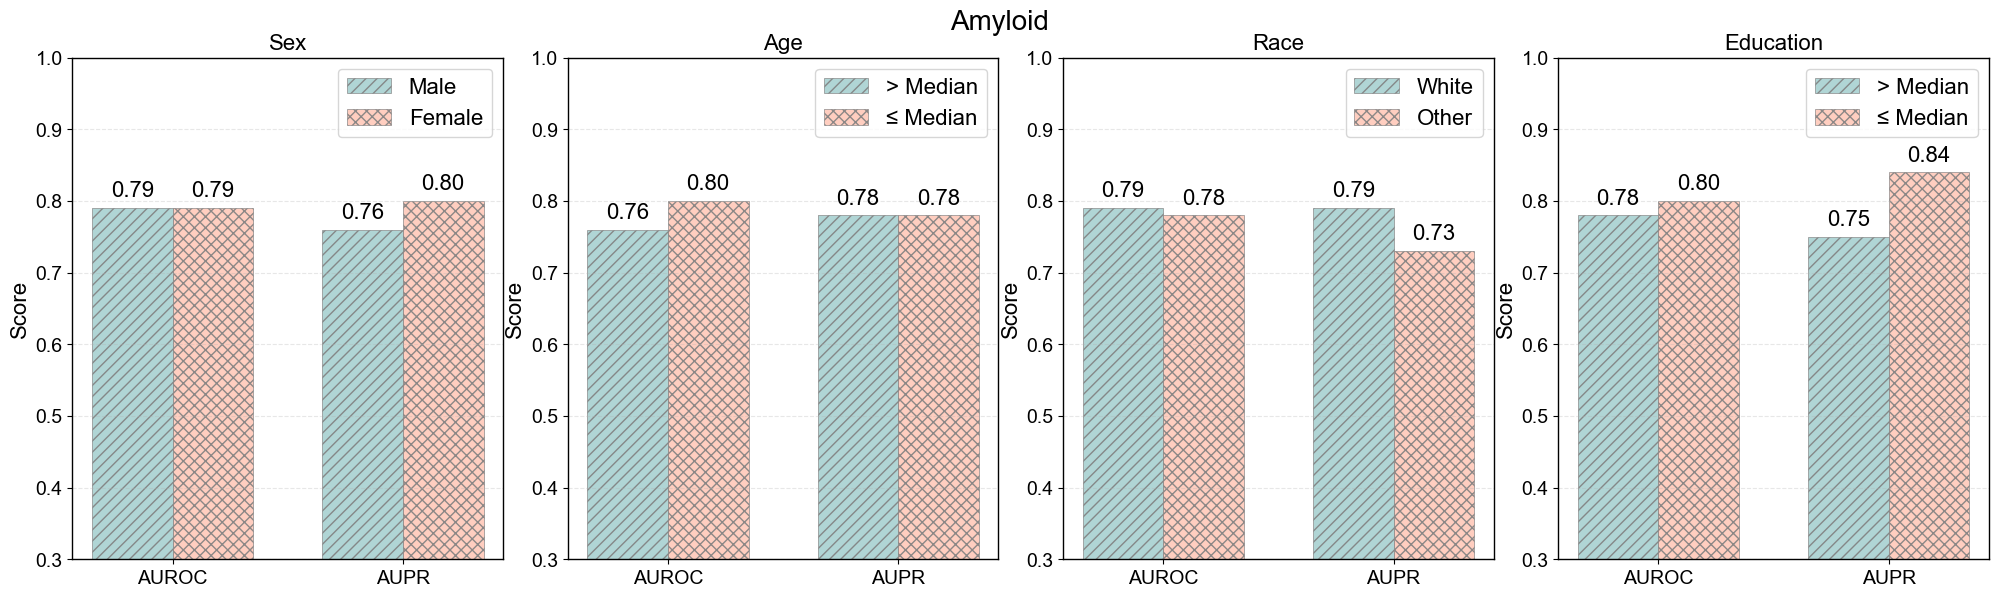

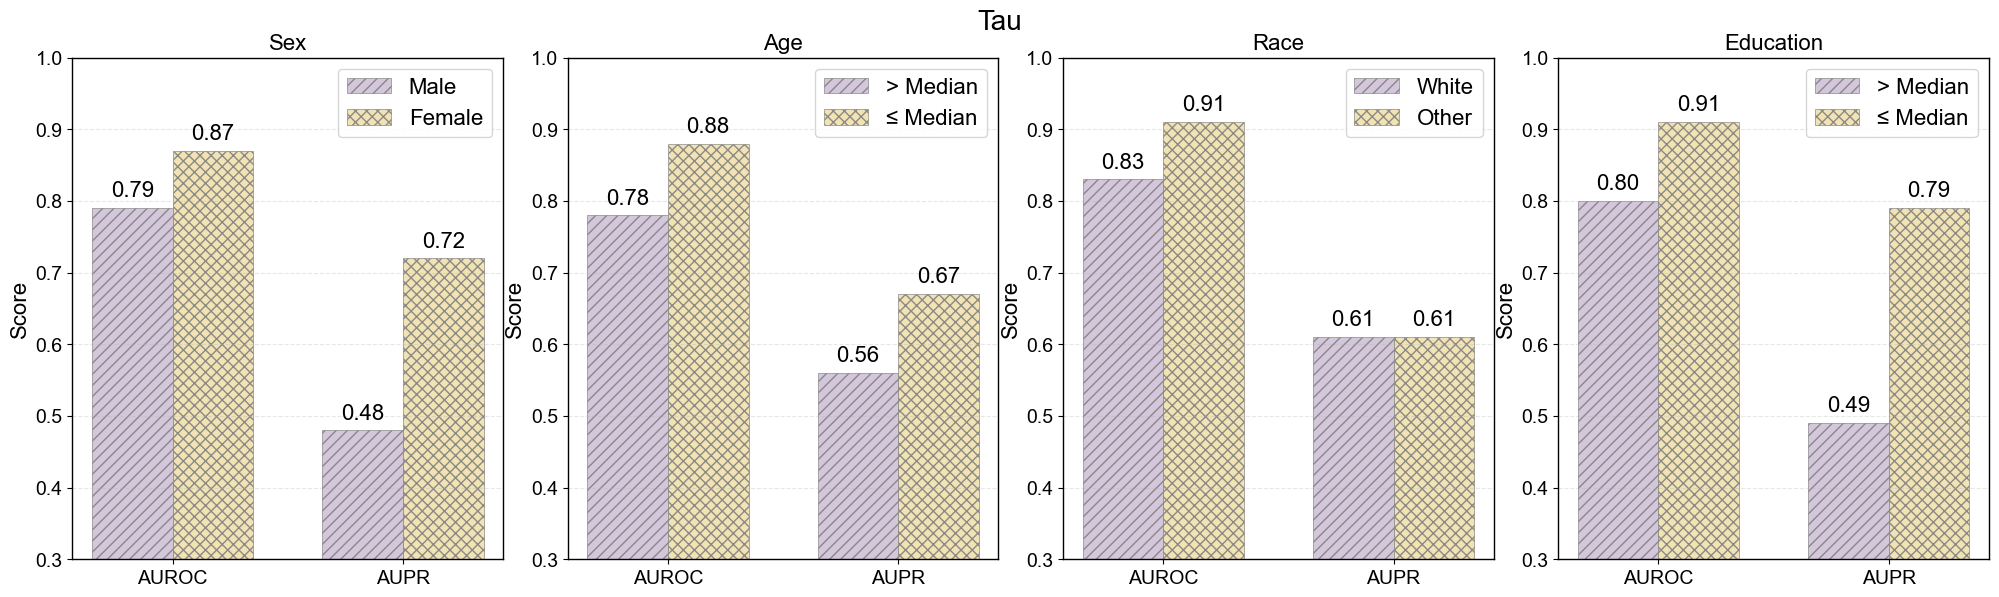

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


amy_data = df[df['Label'] == 'amy_label'].reset_index(drop=True)
tau_data = df[df['Label'] == 'tau_label'].reset_index(drop=True)

amyloid_colors = {
    'cat1': '#A8D1D1',
    'cat2': '#FFC9B9',
}
tau_colors = {
    'cat1': '#D1C1D7',
    'cat2': '#F1E0AC', 
}

hatches = {
    'cat1': '///',
    'cat2': 'xxx' 
}

# Gray color for hatching
hatch_color = '#808080' 

fontsizes = 16
tick_fontsize = 14

def create_model_subplots(model_data, model_name, colors, y_min, y_max, filename):
    fig, axs = plt.subplots(1, 4, figsize=(20, 6))
    subgroups = ['sex', 'age', 'race', 'educ']
    subgroup_labels = {
        'sex': 'Sex',
        'age': 'Age',
        'race': 'Race',
        'educ': 'Education'
    }
    category_labels = {
        'male': 'Male',
        'female': 'Female',
        'age_above_median': '> Median',
        'age_below_median': '≤ Median',
        'whi': 'White',
        'oth': 'Other',
        'educ_above_median': '> Median',
        'educ_below_median': '≤ Median'
    }
    
    for i, subgroup in enumerate(subgroups):
        ax = axs[i]
        subgroup_data = model_data[model_data['Subgroup'] == subgroup].reset_index(drop=True)
        categories = subgroup_data['Category'].tolist()
        x = np.arange(2) 
        width = 0.35 
        
        cat1_bars = ax.bar(x - width/2,
                          [subgroup_data.iloc[0]['AUROC'], subgroup_data.iloc[0]['AUPR']],
                          width, color=colors['cat1'], alpha=0.9,
                          edgecolor='black', linewidth=0.5,
                          label=category_labels[categories[0]], 
                          hatch=hatches['cat1'])
        
        cat2_bars = ax.bar(x + width/2,
                          [subgroup_data.iloc[1]['AUROC'], subgroup_data.iloc[1]['AUPR']],
                          width, color=colors['cat2'], alpha=0.9,
                          edgecolor='black', linewidth=0.5,
                          label=category_labels[categories[1]], 
                          hatch=hatches['cat2'])

        for bar in cat1_bars:
            bar.set_hatch(hatches['cat1'])
            bar.set_edgecolor(hatch_color)
        
        for bar in cat2_bars:
            bar.set_hatch(hatches['cat2'])
            bar.set_edgecolor(hatch_color)
        
        for j, bar in enumerate(cat1_bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f"{height:.2f}", ha='center', va='bottom', fontsize=fontsizes)
        
        for j, bar in enumerate(cat2_bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f"{height:.2f}", ha='center', va='bottom', fontsize=fontsizes)
        
        ax.set_ylabel('Score', fontsize=fontsizes)
        ax.set_title(f'{subgroup_labels[subgroup]}', fontsize=fontsizes)
        
        ax.set_ylim(y_min, y_max)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['AUROC', 'AUPR'], fontsize=tick_fontsize)
        
        ax.tick_params(axis='y', labelsize=tick_fontsize)
        
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        ax.legend(loc='upper right', fontsize=fontsizes)
    
    fig.suptitle(f'{model_name}', fontsize=20, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15, top=0.9)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

create_model_subplots(amy_data, 'Amyloid', amyloid_colors, 0.3, 1, 'pdf_plots/efig1a.pdf')
create_model_subplots(tau_data, 'Tau', tau_colors, 0.3, 1, 'pdf_plots/efig1b.pdf')